# Antispiegel
Load Antispiegel CSV files and create a DataFrame named `df`.

In [58]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Antispiegel"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
pd.reset_option('display.max_colwidth')
df.head()


Loaded 914 rows from 307 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Antispiegel


,Date,Title,Summary,Text,Comments,URL,Full_Text,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Zeichen auf Sturm\nWas das Krisenbarometer Gol...,Egal Anders sagt:\n10. April 2025 um 11:21 Uhr...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Was das Krisenbarometer Gold über Trumps Zoll-...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
1,2025-04-10,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Ich bin auf einen sehr interessanten Artikel g...,"Achtung, Verschwörungstheorie!\nHat die LGBT-P...",TonyOdessa sagt:\n10. April 2025 um 07:11 Uhr\...,https://anti-spiegel.ru/2025/hat-die-lgbt-prop...,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
2,2025-04-10,Will die EU Krieg oder Frieden?,"Die große Frage ist derzeit nicht nur, ob die ...",Ukraine\nWill die EU Krieg oder Frieden?\nDie ...,Grobmotoriker sagt:\n10. April 2025 um 05:31 U...,https://anti-spiegel.ru/2025/will-die-eu-krieg...,Will die EU Krieg oder Frieden? Die große Frag...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
3,2025-04-11,Sind die Russen zu dumm für Propaganda?,"Diese Woche habe ich einen Artikel über die ""W...",Freitagsgedanken\nSind die Russen zu dumm für ...,VladTepes sagt:\n11. April 2025 um 19:04 Uhr\n...,https://anti-spiegel.ru/2025/sind-die-russen-z...,Sind die Russen zu dumm für Propaganda? Diese ...,Antispiegel,antispiegel_tagesartikel_2025-04-12.csv
4,2025-04-11,Mit welchem Trick Paris und London Europa in e...,London und Paris haben anscheinend einen Weg g...,Ukraine-Krieg\nMit welchem Trick Paris und Lon...,TonyOdessa sagt:\n11. April 2025 um 15:40 Uhr\...,https://anti-spiegel.ru/2025/mit-welchem-trick...,Mit welchem Trick Paris und London Europa in e...,Antispiegel,antispiegel_tagesartikel_2025-04-12.csv


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         914 non-null    object
 1   Title        914 non-null    object
 2   Summary      913 non-null    object
 3   Text         914 non-null    object
 4   Comments     236 non-null    object
 5   URL          914 non-null    object
 6   Full_Text    914 non-null    object
 7   source       914 non-null    str   
 8   source_file  914 non-null    str   
dtypes: object(7), str(2)
memory usage: 64.4+ KB


In [60]:
df = df.drop(columns=['Full_Text', 'Comments'])
df.head(1)

,Date,Title,Summary,Text,URL,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Zeichen auf Sturm\nWas das Krisenbarometer Gol...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv


Cut off comments at the end and title etc. at the beginning

In [61]:

df['Text'] = df['Text'].str.split('Teile diesen Beitrag').str[0].str.strip()

In [62]:
df['Text'].str.len().mean()

10024.2647702407

In [63]:
import re

def clean_text(text):
    if pd.isna(text):
        return text
    # Match date pattern followed by time ending with "Uhr" at the start of the article
    # Pattern: day. month year time Uhr (e.g., "10. Februar 2026 20:36 Uhr")
    pattern = r'^.*?\d{1,2}\.\s+\w+\s+\d{4}\s+\d{1,2}:\d{2}\s+Uhr\s*'
    cleaned = re.sub(pattern, '', text, count=1, flags=re.DOTALL)
    return cleaned.strip()

df['Text'] = df['Text'].apply(clean_text)
df.head(2)

,Date,Title,Summary,Text,URL,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Die Finanzmärkte gehen gerade durch eine Krise...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
1,2025-04-10,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Ich bin auf einen sehr interessanten Artikel g...,Ich bin am Mittwoch auf einen Artikel von Dagm...,https://anti-spiegel.ru/2025/hat-die-lgbt-prop...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv


In [64]:
# check length to verify how much was on average deleted at the beginning
df['Text'].str.len().mean()

9669.411378555798

In [65]:
df['Text'] = df['Text'].str.replace('\n', ' ', regex=False)
df.head(2)

,Date,Title,Summary,Text,URL,source,source_file
0,2025-04-10,Was das Krisenbarometer Gold über Trumps Zoll-...,Die Goldpreise brechen Rekorde und derzeit ver...,Die Finanzmärkte gehen gerade durch eine Krise...,https://anti-spiegel.ru/2025/was-das-krisenbar...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv
1,2025-04-10,"Hat die LGBT-Propaganda nur den Zweck, einen g...",Ich bin auf einen sehr interessanten Artikel g...,Ich bin am Mittwoch auf einen Artikel von Dagm...,https://anti-spiegel.ru/2025/hat-die-lgbt-prop...,Antispiegel,antispiegel_tagesartikel_2025-04-11.csv


In [66]:
# Extract relevant time period
df_clean = df[(df['Date'] >= '2025-08-01') & (df['Date'] <= '2026-01-31')].copy()
print(f"Filtered {len(df_clean)} rows from {len(df)} total rows")
pd.reset_option('display.max_colwidth')
df_clean.head()

Filtered 613 rows from 914 total rows


,Date,Title,Summary,Text,URL,source,source_file
269,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...,"Der Streit um das NABU hat gezeigt, dass der W...",Der Streit um das Nationale Anti-Korruptionsbü...,https://anti-spiegel.ru/2025/bereitet-der-west...,Antispiegel,antispiegel_tagesartikel_2025-08-02.csv
270,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...,Die New York Times berichtet über ein Schreibe...,Die New York Times versucht seit langem vor Ge...,https://anti-spiegel.ru/2025/eu-kommission-hat...,Antispiegel,antispiegel_tagesartikel_2025-08-02.csv
271,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...,Die Chefin der moldawischen Wahlkommission hat...,Ende September stehen in Moldawien Parlamentsw...,https://anti-spiegel.ru/2025/wahlkommission-re...,Antispiegel,antispiegel_tagesartikel_2025-08-02.csv
272,2025-08-02,Fordert Russland wirklich die Vernichtung alle...,"Die Überschrift des RIA-Artikels ""Niemand darf...",Ich bin auf die Geschichte zuerst bei RT-DE ge...,https://anti-spiegel.ru/2025/fordert-russland-...,Antispiegel,antispiegel_tagesartikel_2025-08-03.csv
273,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...,"Es ist immer wieder erstaunlich, mit welcher V...","Wer auch nicht-westliche Medien liest, der ist...",https://anti-spiegel.ru/2025/der-spiegel-macht...,Antispiegel,antispiegel_tagesartikel_2025-08-03.csv


In [67]:
df_clean['Date'].min()

'2025-08-01'

In [68]:
df_clean['Date'].max()

'2026-01-31'

In [69]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 613 entries, 269 to 881
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         613 non-null    object
 1   Title        613 non-null    object
 2   Summary      612 non-null    object
 3   Text         613 non-null    str   
 4   URL          613 non-null    object
 5   source       613 non-null    str   
 6   source_file  613 non-null    str   
dtypes: object(4), str(3)
memory usage: 33.7+ KB


In [70]:
# Check duplicates by URL
url_duplicates = df_clean[df_clean.duplicated(subset=['URL'], keep=False)]
print(f"Duplicate URLs: {len(url_duplicates)} rows ({url_duplicates['URL'].nunique()} unique URLs)")

# Check duplicates by Title
title_duplicates = df_clean[df_clean.duplicated(subset=['Title'], keep=False)]
print(f"Duplicate Titles: {len(title_duplicates)} rows ({title_duplicates['Title'].nunique()} unique Titles)")

# Check duplicates by Text
text_duplicates = df_clean[df_clean.duplicated(subset=['Text'], keep=False)]
print(f"Duplicate Text: {len(text_duplicates)} rows")

# Show duplicate URLs if any
if len(url_duplicates) > 0:
    print("\n--- Sample Duplicate URLs ---")
    print(url_duplicates[['Date', 'Title', 'URL']].head(10))

Duplicate URLs: 0 rows (0 unique URLs)
Duplicate Titles: 0 rows (0 unique Titles)
Duplicate Text: 0 rows


In [71]:
# Remove articles where Title contains "Tacheles #" as this is podcast advertismenet
df_clean = df_clean[~df_clean["Title"].str.contains("Tacheles #", na=False)]
print(f"Rows after removing 'Tacheles #' articles: {len(df_clean):,}")

Rows after removing 'Tacheles #' articles: 589


In [72]:
# Count articles containing "podcast" (case-insensitive)
podcast_mask = df_clean['Text'].str.contains('podcast', case=False, na=False)
podcast_articles = df_clean[podcast_mask]

print(f"Articles containing 'podcast': {len(podcast_articles)} out of {len(df_clean)} ({len(podcast_articles)/len(df_clean)*100:.1f}%)")
print("\nSample titles of podcast articles:")
print(podcast_articles['Title'].head(10).tolist())

# Check if these are mainly podcast announcements vs articles mentioning podcasts
print("\n--- Examining article lengths ---")
print(f"Mean length of podcast articles: {podcast_articles['Text'].str.len().mean():.0f} chars")
print(f"Mean length of non-podcast articles: {df_clean[~podcast_mask]['Text'].str.len().mean():.0f} chars")

# Show a few examples to understand the content
print("\n--- Sample Text snippets from podcast articles ---")
for i, (idx, row) in enumerate(podcast_articles.head(3).iterrows()):
    print(f"\n[{i+1}] Title: {row['Title'][:80]}...")
    print(f"    Text preview: {row['Text'][:300]}...")

Articles containing 'podcast': 26 out of 589 (4.4%)

Sample titles of podcast articles:
['Eine geopolitische Weltreise', 'Nächste Woche wird es spannend', 'Diesen Artikel darüber, warum der Ukraine-Krieg schnell beendet werden muss, sollte man in der EU lesen!', 'Die 7 Zwerge aus Europa bei Trump', 'Deutschland geht für die Ukraine vor die Hunde', 'Warum gelingt es in Russland, dass Christen und Moslems problemlos zusammenleben?', 'Drohnen über Polen und Reaktionen auf Kommentare von Zuhörern über Russland', 'Gibt es in Russland eigentlich eine Opposition?', 'Manipulierte Wahlen in Moldawien und Antworten auf Hörerfragen', 'Wie ist das Gesundheitssystem in Russland?']

--- Examining article lengths ---
Mean length of podcast articles: 1479 chars
Mean length of non-podcast articles: 10274 chars

--- Sample Text snippets from podcast articles ---

[1] Title: Eine geopolitische Weltreise...
    Text preview: Dieses Mal haben wir beim Anti-Spiegel-Podcast mehrere Themenkomplexe behandelt, 

## EDA

In [73]:
# Create a table showing number of articles per month
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
articles_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

,month,article_count
0,2025-08,90
1,2025-09,118
2,2025-10,108
3,2025-11,81
4,2025-12,110
5,2026-01,82


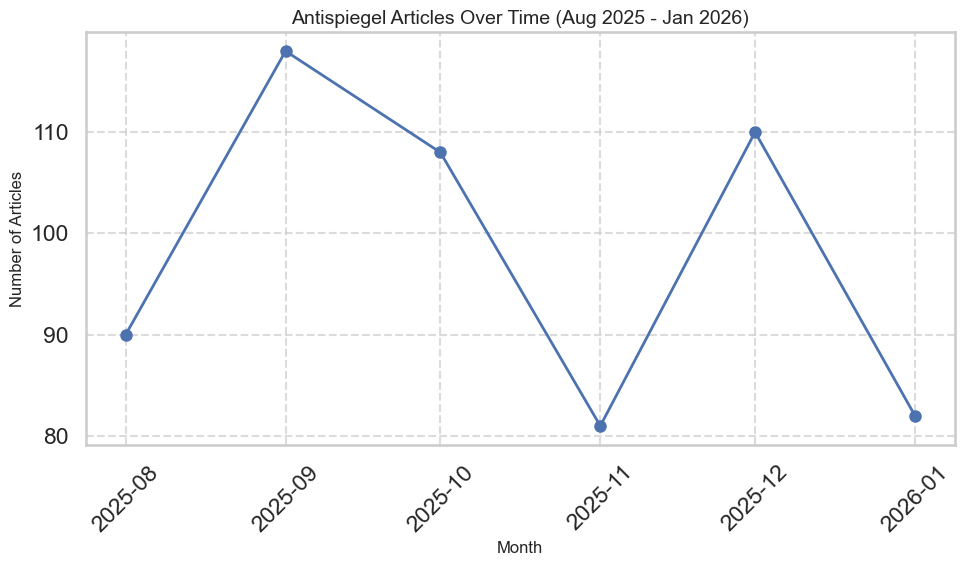

In [74]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Antispiegel Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [75]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

eda_df["Text"] = eda_df["Text"].astype("string")
eda_df = eda_df.dropna(subset=["Date", "Text"]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 589


In [76]:
eda_df["article_length_words"] = eda_df["Text"].str.split().str.len()
eda_df["article_length_chars"] = eda_df["Text"].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count     589.0
mean     1390.3
std       822.1
min        39.0
10%       464.8
25%       859.0
50%      1318.0
75%      1808.0
90%      2264.2
95%      2853.4
99%      3919.7
max      6766.0
Name: article_length_words, dtype: float64

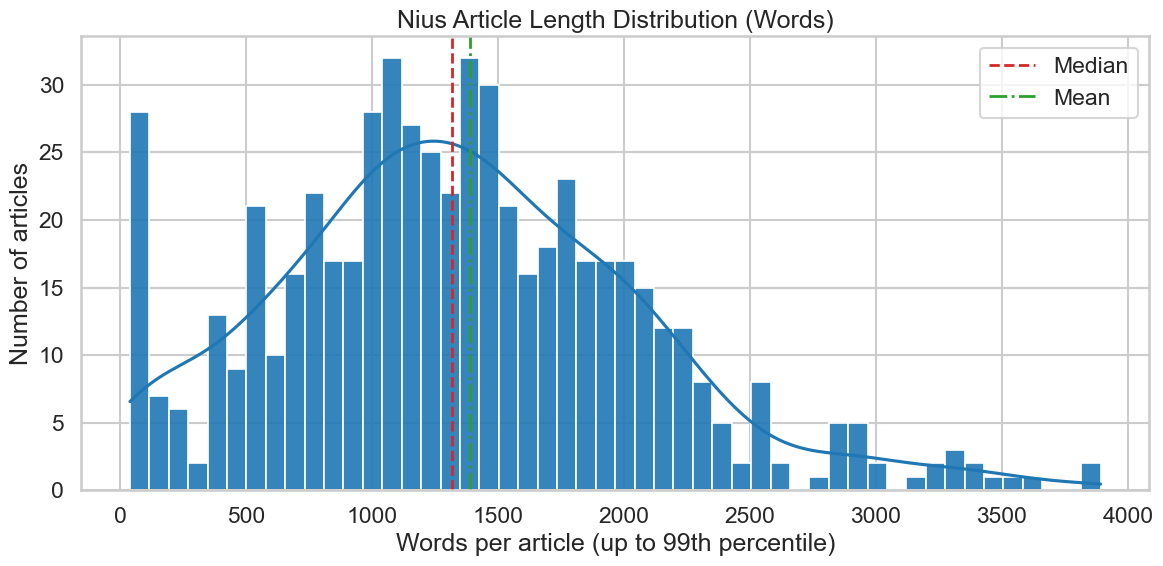

In [77]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Nius Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [78]:
# Filter articles with low word count (first bar in histogram, approximately 0-100 words)
low_word_articles = eda_df[eda_df["article_length_words"] <= 200]

print(f"Number of articles with <= 100 words: {len(low_word_articles)}")
low_word_articles[["Date", "Title", "Text", "article_length_words"]].sort_values("article_length_words")

Number of articles with <= 100 words: 35


,Date,Title,Text,article_length_words
476,2025-09-29,Manipulierte Wahlen in Moldawien und Antworten...,Diese Woche ist der Anti-Spiegel-Podcast ein M...,39
289,2025-08-08,Nächste Woche wird es spannend,Das beherrschende Thema dieses Anti-Spiegel-Po...,50
812,2026-01-12,Bedeuten Trumps Ambitionen auf Grönland das En...,Die ersten Tage des neuen Jahres haben große g...,55
500,2025-10-06,Wie ist das Gesundheitssystem in Russland?,Diese Folge des Anti-Spiegel-Podcasts beginnen...,59
423,2025-09-15,Drohnen über Polen und Reaktionen auf Kommenta...,Da der Anti-Spiegel-Podcast nun aus zwei Theme...,60
649,2025-11-17,Interview mit dem sächsischen AfD-Chef Jörg Urban,Der Fraktionsvorsitzenden der AfD im sächsisch...,62
452,2025-09-22,Gibt es in Russland eigentlich eine Opposition?,Im politischen Teil des Podcasts ging es diese...,63
327,2025-08-23,Die 7 Zwerge aus Europa bei Trump,Natürlich war das Treffen von Trump mit Selens...,65
721,2025-12-08,Wie Korruption im Westen als politisches Druck...,Im politischen Teil des Anti-Spiegel-Podcast g...,78
462,2025-09-25,Interview mit den Anwälten von Thomas Röper un...,Markus Fiedler hat für apolut ein Interview mi...,79


Even with a peak of articles containing a low number of words, it was decided to leave those short articles in as after manual check they seem to meaningfully contribute to the overall dataset in terms of discussed topics etc.

## EDA

In [79]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [80]:
from BERTopic.bertopic_config import BERTopicConfig, title_config
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [81]:
# Full-text config for Antispiegel topic modeling
config_full_text = BERTopicConfig(
    min_text_chars=80,
    min_tokens=12,
    min_df=2,
    max_df=0.75,
    ngram_range=(1, 3),
    umap_n_neighbors=8,
    umap_n_components=5,
    umap_min_dist=0.0,
    hdbscan_min_cluster_size=4,
    hdbscan_min_samples=2,
    extra_stopwords=(
        "für", "hat", "haben", "wird", "werden", "wurde",
        "sagte", "sagt", "sei", "sind",
        "antispiegel", "artikel", "podcast", "video", "spotify",
    ),
)

# Title-only config for Antispiegel topic modeling
config_title = title_config(
    ngram_range=(1, 2),
    hdbscan_min_cluster_size=4,
    hdbscan_min_samples=2,
    extra_stopwords=(
        "für", "hat", "haben", "wird", "werden", "wurde",
        "sagte", "sagt", "sei", "sind",
        "antispiegel", "artikel", "podcast", "video", "spotify",
    ),
)


In [82]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=config_full_text,
    id_col="URL",
    source_name="Antispiegel",
)

# 2) BERTopic on titles only
result_title = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=config_title,
    id_col="URL",
    source_name="Antispiegel",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 11:56:49,716 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

2026-03-09 11:56:53,048 - BERTopic - Embedding - Completed ✓
2026-03-09 11:56:53,048 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 11:56:53,585 - BERTopic - Dimensionality - Completed ✓
2026-03-09 11:56:53,586 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 11:56:53,601 - BERTopic - Cluster - Completed ✓
2026-03-09 11:56:53,603 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 11:56:54,722 - BERTopic - Representation - Completed ✓


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 11:57:06,107 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

2026-03-09 11:57:06,977 - BERTopic - Embedding - Completed ✓
2026-03-09 11:57:06,978 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 11:57:07,795 - BERTopic - Dimensionality - Completed ✓
2026-03-09 11:57:07,796 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 11:57:07,805 - BERTopic - Cluster - Completed ✓
2026-03-09 11:57:07,806 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 11:57:07,822 - BERTopic - Representation - Completed ✓


In [83]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,89,-1_selensky_euro_frankreich_dollar,"[selensky, euro, frankreich, dollar, saluschny...",[Denis Dubrowin ist Korrespondent der russisch...
1,0,40,0_demokraten_haus_weißen_selensky,"[demokraten, haus, weißen, selensky, dollar, w...",[Die letzte politische Woche in den USA war so...
2,1,19,1_fernen_fernen osten_uschakow_osten,"[fernen, fernen osten, uschakow, osten, möchte...","[Aus Russland sind, wenn man von Präsident Put..."
3,2,18,2_wahlen_moldawien_wahl_moldawischen,"[wahlen, moldawien, wahl, moldawischen, sandu,...",[Den ersten Meldungen zufolge ist die Parlamen...
4,3,16,3_polen_polnische_polnischen_nord,"[polen, polnische, polnischen, nord, gericht, ...",[Aus aktuellem Anlass veröffentliche ich hier ...
5,4,14,4_vk_vk anhören_anhören_russischen vk anhören,"[vk, vk anhören, anhören, russischen vk anhöre...",[Diese Woche ist der Anti-Spiegel-Podcast ein ...
6,5,13,5_merz_bundeskanzler_sozialstaat_indien,"[merz, bundeskanzler, sozialstaat, indien, fri...","[Ich habe bereits in einem Artikel erklärt, wi..."
7,6,13,6_aserbaidschan_iran_georgien_georgische,"[aserbaidschan, iran, georgien, georgische, ar...",[Ich berichte viel über die Entwicklungen im S...
8,7,12,7_grönland_dänemark_kanada_grönlands,"[grönland, dänemark, kanada, grönlands, dänisc...",[In der Washington Post in ein Artikel über de...
9,8,12,8_merz_macron_koalition_willigen,"[merz, macron, koalition, willigen, koalition ...",[Wie immer freue ich mich auf den Bericht des ...


In [84]:
doc_info = result["doc_info"]
doc_info.head()

,original_index,document_id,source_name,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,269,https://anti-spiegel.ru/2025/bereitet-der-west...,Antispiegel,Der Streit um das Nationale Anti-Korruptionsbü...,24,24_nabu_selensky_timoschenko_selenskys,"[nabu, selensky, timoschenko, selenskys, jerma...",[In der Nacht auf Mittwoch hat das Nationale A...,nabu - selensky - timoschenko - selenskys - je...,1.000000,True
1,270,https://anti-spiegel.ru/2025/eu-kommission-hat...,Antispiegel,Die New York Times versucht seit langem vor Ge...,56,56_merkel_minsker_2021_minsker abkommen,"[merkel, minsker, 2021, minsker abkommen, abko...",[Die New York Times versucht seit langem vor G...,merkel - minsker - 2021 - minsker abkommen - a...,1.000000,True
2,271,https://anti-spiegel.ru/2025/wahlkommission-re...,Antispiegel,Ende September stehen in Moldawien Parlamentsw...,2,2_wahlen_moldawien_wahl_moldawischen,"[wahlen, moldawien, wahl, moldawischen, sandu,...",[Den ersten Meldungen zufolge ist die Parlamen...,wahlen - moldawien - wahl - moldawischen - san...,0.450632,False
3,272,https://anti-spiegel.ru/2025/fordert-russland-...,Antispiegel,Ich bin auf die Geschichte zuerst bei RT-DE ge...,16,16_cia_reitschuster_modi_indien,"[cia, reitschuster, modi, indien, entwickelt, ...",[Ich bin zufällig auf einen Artikel eines russ...,cia - reitschuster - modi - indien - entwickel...,0.292547,False
4,273,https://anti-spiegel.ru/2025/der-spiegel-macht...,Antispiegel,"Wer auch nicht-westliche Medien liest, der ist...",-1,-1_selensky_euro_frankreich_dollar,"[selensky, euro, frankreich, dollar, saluschny...",[Denis Dubrowin ist Korrespondent der russisch...,selensky - euro - frankreich - dollar - salusc...,0.000000,False


In [85]:
Antispiegel_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

In [86]:
Antispiegel_topics.info()

<class 'pandas.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           589 non-null    int64         
 1   Date            589 non-null    datetime64[us]
 2   Title           589 non-null    object        
 3   Summary         588 non-null    object        
 4   Text            589 non-null    str           
 5   URL             589 non-null    object        
 6   source          589 non-null    str           
 7   source_file     589 non-null    str           
 8   original_index  589 non-null    int64         
 9   Topic           589 non-null    int64         
 10  Name            589 non-null    str           
 11  Probability     589 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(3), object(3), str(4)
memory usage: 55.3+ KB


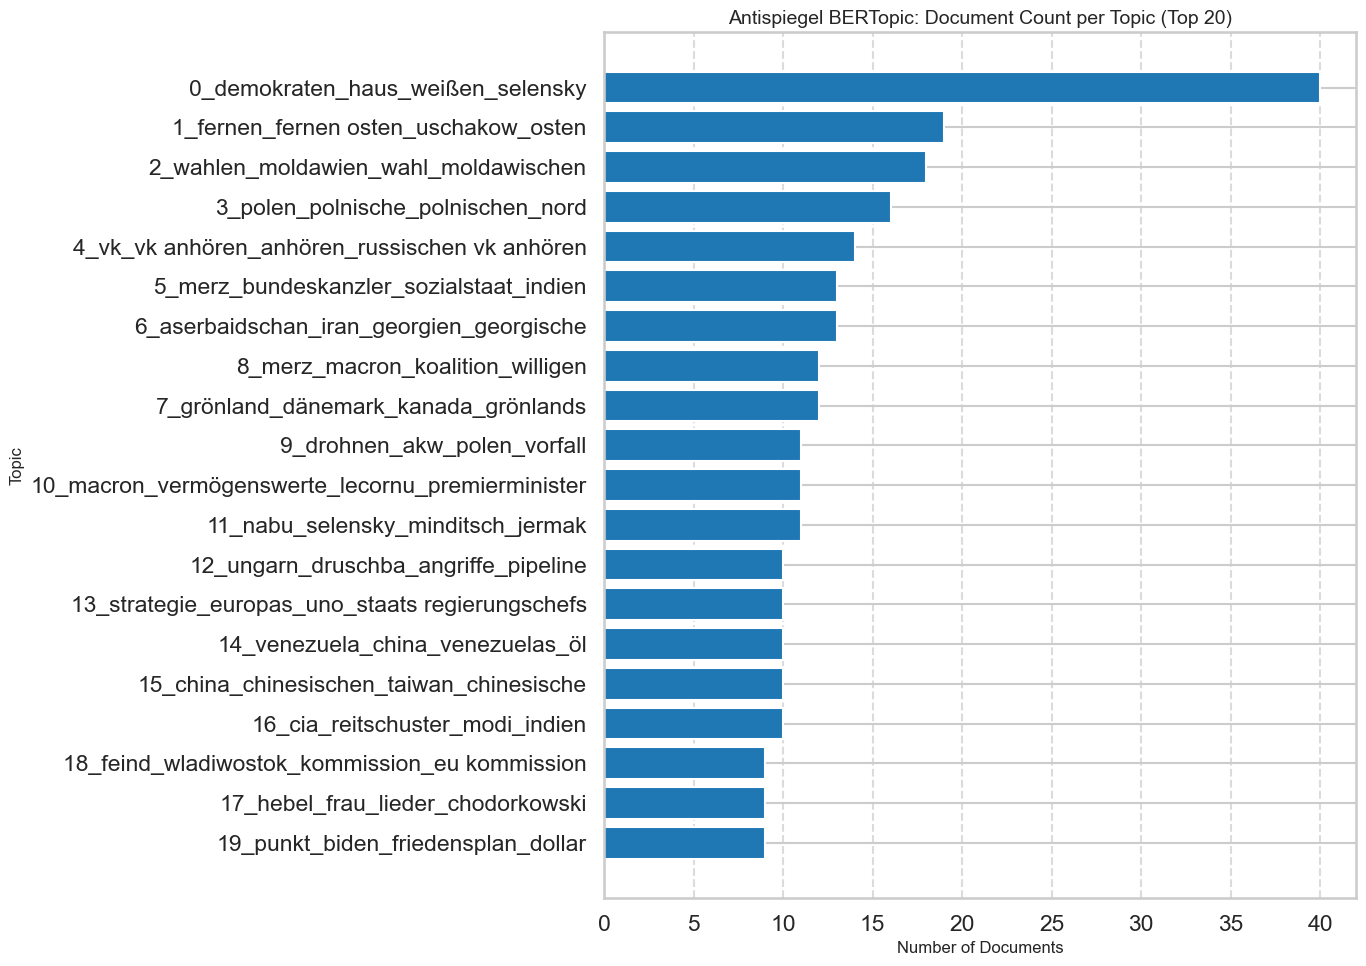

In [87]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) and get top 20 topics by count
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.nlargest(20, 'Count').sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Antispiegel BERTopic: Document Count per Topic (Top 20)', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:01,  3.06it/s]


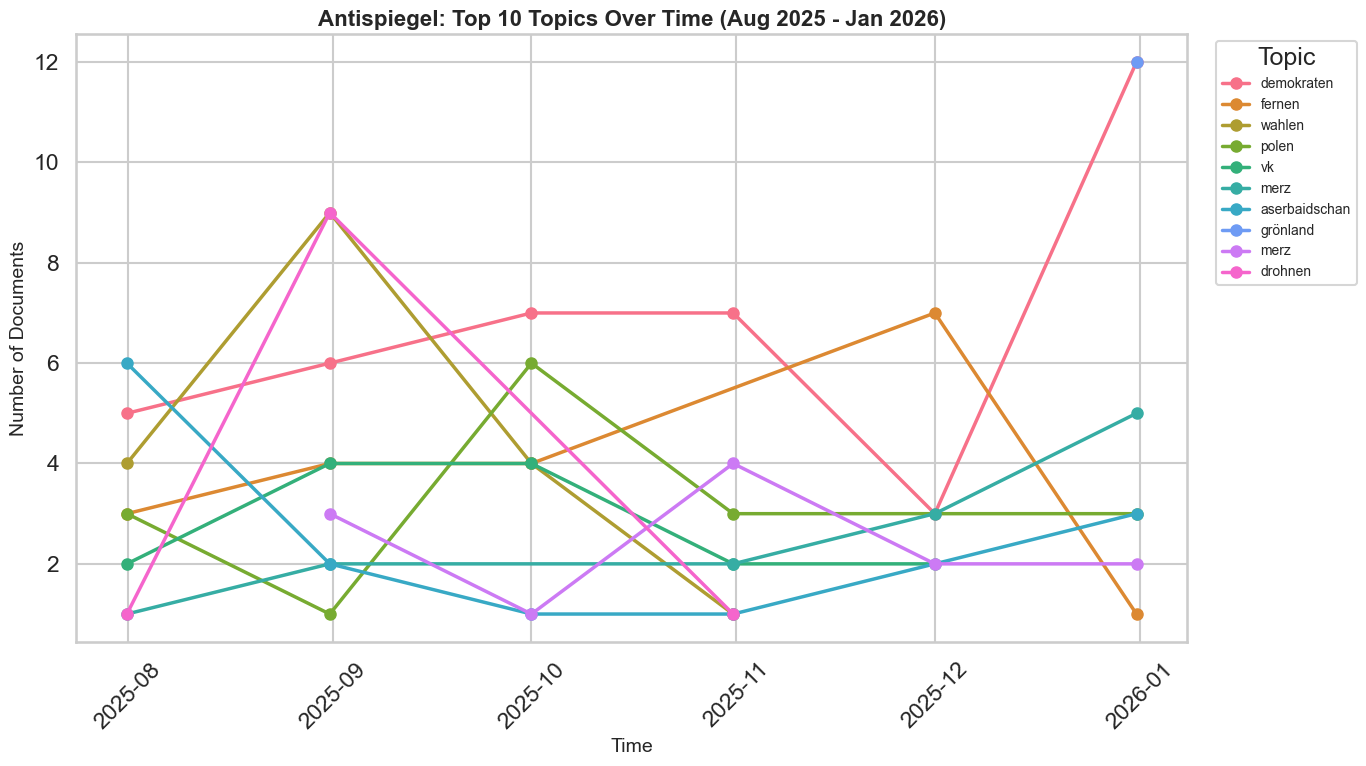

In [88]:
# Prepare data for topics over time
topics_over_time = result["topic_model"].topics_over_time(
    result["docs"],
    result["prepared_documents"]["Date"].tolist(),
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Antispiegel: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
# Final BERTopic comparison table: all topics + representative words
from IPython.display import display

topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

def _representative_words_for_topic(topic_id: int) -> str:
    terms = result["topic_model"].get_topic(int(topic_id)) or []
    return ", ".join(word for word, _ in terms)

topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(topics_comparison_df)


,Topic,Name,Count,Representative_Words
0,-1,-1_selensky_euro_frankreich_dollar,89,"selensky, euro, frankreich, dollar, saluschny, korruption, ungarn, brüssel, brics, indien"
1,0,0_demokraten_haus_weißen_selensky,40,"demokraten, haus, weißen, selensky, dollar, whistleblower, new, soros, us präsident, bbc"
2,1,1_fernen_fernen osten_uschakow_osten,19,"fernen, fernen osten, uschakow, osten, möchte, entwicklung, regionen, interessen, region, putins"
3,2,2_wahlen_moldawien_wahl_moldawischen,18,"wahlen, moldawien, wahl, moldawischen, sandu, gagausen, wahlkommission, opposition, parlamentswahlen, partei"
4,3,3_polen_polnische_polnischen_nord,16,"polen, polnische, polnischen, nord, gericht, ukrainer, nord stream, stream, warschau, ostsee"
...,...,...,...,...
56,55,55_merz_merkel_schröder_deutschlands,4,"merz, merkel, schröder, deutschlands, kanzler, chodorkowski, scholz, globalen, altersarmut, deutschen europäischen"
57,56,56_merkel_minsker_2021_minsker abkommen,4,"merkel, minsker, 2021, minsker abkommen, abkommen, donbass, interview, november 2021, kommission, merkels"
58,57,57_schiffe_tanker_ostsee_schattenflotte,4,"schiffe, tanker, ostsee, schattenflotte, gekapert, britischen regierung, schiffen, kapern, hafen, brief"
59,58,58_grönland_davos_dänemark_solidarität,4,"grönland, davos, dänemark, solidarität, schweigen, soldaten grönland, vasallen, strafzölle, carney, eu staaten"


In [90]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Antispiegel"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

# Keep a dedicated Text column and normalize expected column aliases.
if "Text" not in df.columns and "article_text" in df.columns:
    df["Text"] = df["article_text"]
if "title" not in df.columns and "Title" in df.columns:
    df["title"] = df["Title"]
if "date" not in df.columns and "Date" in df.columns:
    df["date"] = df["Date"]
if "url" not in df.columns and "URL" in df.columns:
    df["url"] = df["URL"]

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")

Loaded 914 rows from 307 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Antispiegel


In [91]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [92]:
from BERTopic.bertopic_config import BERTopicConfig
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

In [93]:
# Prepare Antispiegel dataframe for topic modeling
df_clean = df[["title", "date", "url", "Text"]].copy()
df_clean["day"] = pd.to_datetime(df_clean["date"], errors="coerce")

df_clean["Text"] = (
    df_clean["Text"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df_clean["title"] = (
    df_clean["title"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df_clean = df_clean.dropna(subset=["day", "url", "Text"]).copy()

df_clean = df_clean[
    (df_clean["day"] >= "2025-08-01") & (df_clean["day"] <= "2026-01-31")
].copy()

print(f"Rows prepared for BERTopic: {len(df_clean):,}")
df_clean[["title", "Text", "day", "url"]].head()

Rows prepared for BERTopic: 613


,title,Text,day,url
269,Bereitet der Westen die Entmachtung oder sogar...,Machtkampf ums NABU Bereitet der Westen die En...,2025-08-01,https://anti-spiegel.ru/2025/bereitet-der-west...
270,EU-Kommission hat Textnachrichten zum Kauf der...,Korruption EU-Kommission hat Textnachrichten z...,2025-08-01,https://anti-spiegel.ru/2025/eu-kommission-hat...
271,Wahlkommission rechtfertigt Einmischung der EU...,Moldawien Wahlkommission rechtfertigt Einmisch...,2025-08-01,https://anti-spiegel.ru/2025/wahlkommission-re...
272,Fordert Russland wirklich die Vernichtung alle...,Behauptung von Reitschuster&Co. Fordert Russla...,2025-08-02,https://anti-spiegel.ru/2025/fordert-russland-...
273,Der Spiegel macht mal wieder Berichterstattung...,Selensky und das NABU-Gesetz Der Spiegel macht...,2025-08-02,https://anti-spiegel.ru/2025/der-spiegel-macht...


In [94]:
# BERTopic on full article text
result = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=8),
    id_col="url",
    source_name="Antispiegel",
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 11:57:18,038 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

2026-03-09 11:57:21,149 - BERTopic - Embedding - Completed ✓
2026-03-09 11:57:21,150 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 11:57:21,945 - BERTopic - Dimensionality - Completed ✓
2026-03-09 11:57:21,946 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 11:57:21,955 - BERTopic - Cluster - Completed ✓
2026-03-09 11:57:21,956 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 11:57:22,868 - BERTopic - Representation - Completed ✓


In [95]:
import pandas as pd

pd.set_option("display.max_colwidth", None)

topic_info = result["topic_info"].copy()
topic_info["Representation_str"] = topic_info["Representation"].apply(
    lambda x: ", ".join(x) if isinstance(x, (list, tuple)) else str(x)
)

topic_info[["Topic", "Count", "Name", "Representation_str"]].head(50)

,Topic,Count,Name,Representation_str
0,-1,243,-1_gas_ukrainischen_kiew_merz,"gas, ukrainischen, kiew, merz, raketen, drohnen, ukrainische, 2022, öl, indien"
1,0,56,0_schreibt_leser_afd_meinungsfreiheit,"schreibt, leser, afd, meinungsfreiheit, überschrift, bbc, demokratie, gesetz, bundesregierung, ki"
2,1,43,1_selensky_nabu_ukrainischen_selenskys,"selensky, nabu, ukrainischen, selenskys, ukrainische, minditsch, jermak, korruptionsskandal, kiew, maidan"
3,2,38,2_selensky_friedensplan_kiew_sicherheitsgarantien,"selensky, friedensplan, kiew, sicherheitsgarantien, ukrainischen, für ukraine, gespräche, aserbaidschan, waffenstillstand, ukrainische"
4,3,32,3_österreich_atomwaffen_gegen russland_raketen,"österreich, atomwaffen, gegen russland, raketen, rakete, burevestnik, nuklearen, afrika, britischen, neutralität"
5,4,26,4_moldawien_wahlen_wahl_sandu,"moldawien, wahlen, wahl, sandu, moldawischen, moldawische, wahlkommission, parlamentswahlen, opposition, wahllokale"
6,5,25,5_gaza_israel_iran_hamas,"gaza, israel, iran, hamas, netanjahu, israelische, israelischen, gazastreifen, friedensrat, israels"
7,6,24,6_tacheles_sendung_nuoviso_youtube,"tacheles, sendung, nuoviso, youtube, youtube sendung, stein, löschen, sollte youtube, anschauen, nuoviso anschauen"
8,7,22,7_ukrainischen_ungarn_ukrainische_akw,"ukrainischen, ungarn, ukrainische, akw, kiew, drohnen, streitkräfte, pipeline, front, öl"
9,8,22,8_demokraten_dollar_selensky_new,"demokraten, dollar, selensky, new, biden, york, weißen, new york, bericht, soros"


In [96]:
# BERTopic quality metrics
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


metrics = evaluate_bertopic(
    docs=result["docs"],
    topic_model=result["topic_model"],
    top_k=10,
)
metrics


Python(96364) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96366) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96369) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96371) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96373) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96375) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96377) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96380) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(96383) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


{'coherence_npmi': 0.021531262514210853,
 'topic_diversity': 0.9142857142857143,
 'num_topics': 14,
 'top_k': 10}

In [97]:
doc_info = result["doc_info"].copy()

# Compact topic overview: number of linked documents per topic (no long text columns).
group_cols = [c for c in ["Topic", "Name"] if c in doc_info.columns]
doc_info_overview = (
    doc_info.groupby(group_cols, dropna=False)
    .size()
    .reset_index(name="Doc_Count")
    .sort_values("Doc_Count", ascending=False)
    .reset_index(drop=True)
)

if "Probability" in doc_info.columns:
    avg_prob = (
        doc_info.groupby(group_cols, dropna=False)["Probability"]
        .mean()
        .reset_index(name="Avg_Probability")
    )
    doc_info_overview = doc_info_overview.merge(avg_prob, on=group_cols, how="left")
    doc_info_overview["Avg_Probability"] = doc_info_overview["Avg_Probability"].round(3)

if "Name" in doc_info_overview.columns:
    doc_info_overview["Name"] = doc_info_overview["Name"].astype("string").str.slice(0, 60)

doc_info_overview


,Topic,Name,Doc_Count,Avg_Probability
0,-1,-1_gas_ukrainischen_kiew_merz,243,0.000
1,0,0_schreibt_leser_afd_meinungsfreiheit,56,0.845
2,1,1_selensky_nabu_ukrainischen_selenskys,43,0.696
3,2,2_selensky_friedensplan_kiew_sicherheitsgarantien,38,0.963
4,3,3_österreich_atomwaffen_gegen russland_raketen,32,0.943
5,4,4_moldawien_wahlen_wahl_sandu,26,0.665
6,5,5_gaza_israel_iran_hamas,25,0.659
7,6,6_tacheles_sendung_nuoviso_youtube,24,0.805
8,7,7_ukrainischen_ungarn_ukrainische_akw,22,0.937
9,8,8_demokraten_dollar_selensky_new,22,0.897


In [98]:
antispiegel_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

# Compact overview display (no full article text column).
display_cols = [c for c in ["day", "title", "Topic", "Name", "Probability"] if c in antispiegel_topics.columns]
antispiegel_topics[display_cols].head()


,day,title,Topic,Name,Probability
0,2025-08-01,Bereitet der Westen die Entmachtung oder sogar den Sturz Selenskys vor?,1,1_selensky_nabu_ukrainischen_selenskys,0.652280
1,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der Pfizer-Impfstoffe erst nach Anfragen von Journalisten gelöscht,0,0_schreibt_leser_afd_meinungsfreiheit,0.601185
2,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU in die anstehenden Parlamentswahlen,4,4_moldawien_wahlen_wahl_sandu,0.555287
3,2025-08-02,Fordert Russland wirklich die Vernichtung aller Ukrainer?,-1,-1_gas_ukrainischen_kiew_merz,0.000000
4,2025-08-02,Der Spiegel macht mal wieder Berichterstattung für den Kindergarten,0,0_schreibt_leser_afd_meinungsfreiheit,0.991861


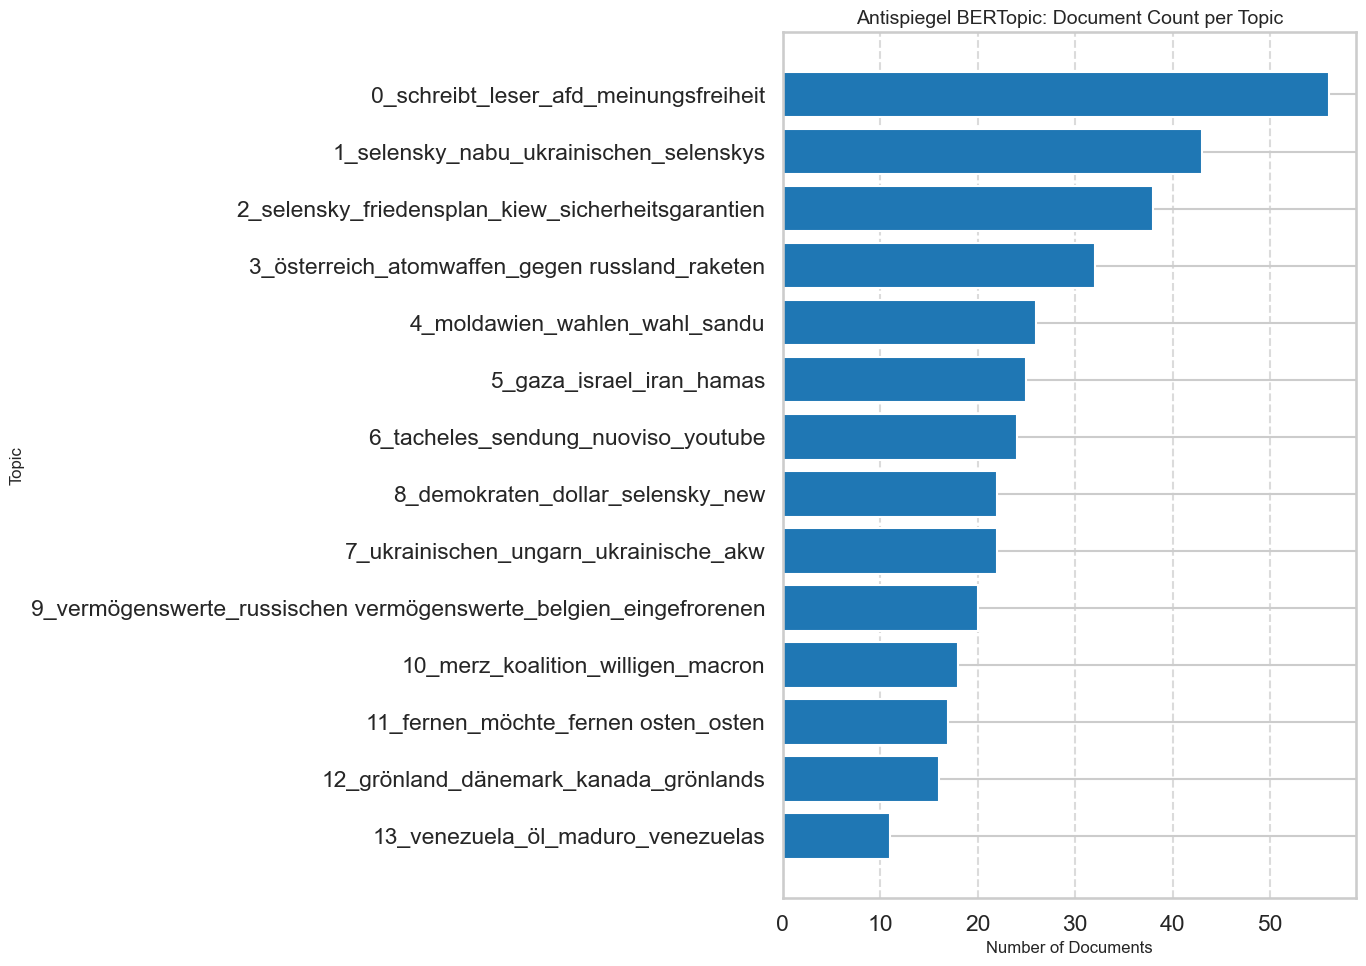

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info["Topic"] != -1].copy()
topic_counts = topic_counts.nlargest(20, "Count").sort_values("Count", ascending=True)

ax.barh(topic_counts["Name"], topic_counts["Count"], color="#1f77b4", edgecolor="white")

ax.set_xlabel("Number of Documents", fontsize=12)
ax.set_ylabel("Topic", fontsize=12)
ax.set_title("Antispiegel BERTopic: Document Count per Topic", fontsize=14)
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


6it [00:01,  3.14it/s]


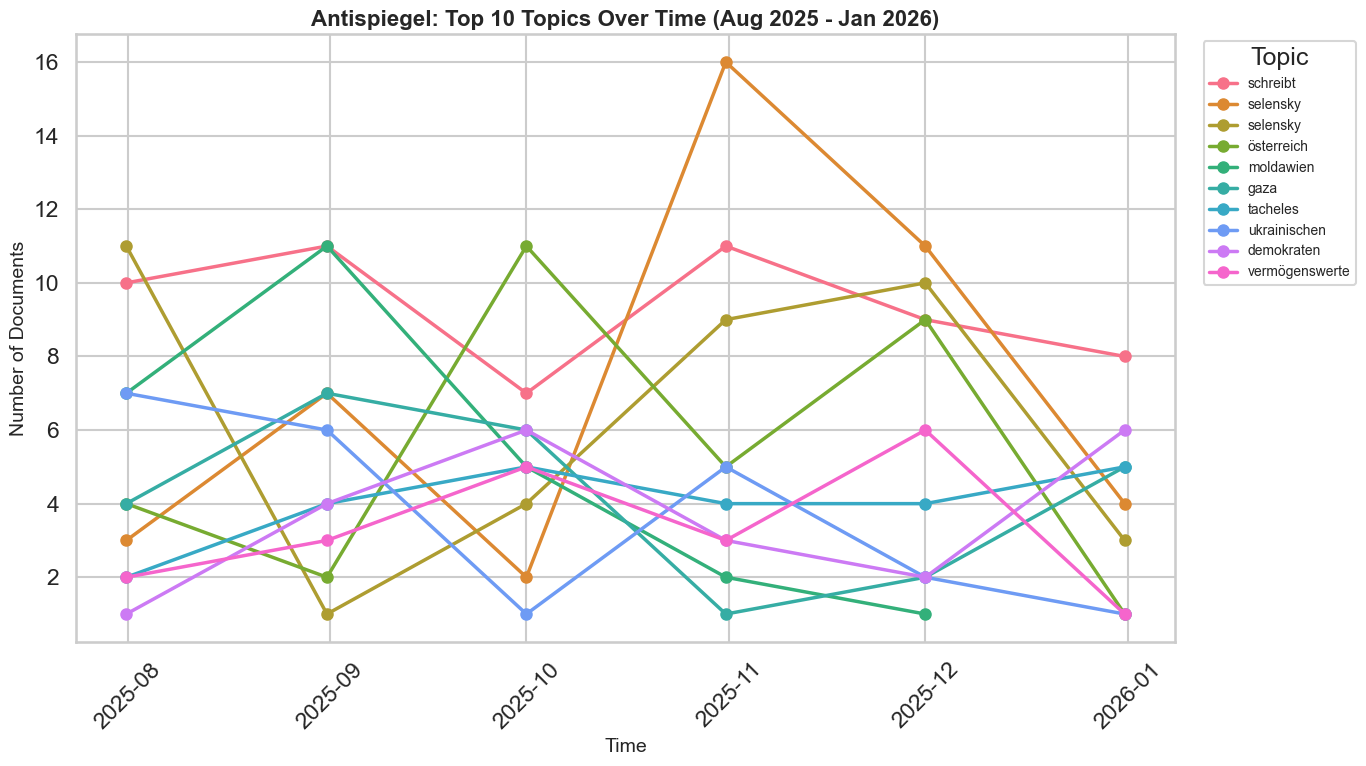

In [100]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["day"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6,
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info["Topic"] != -1].nlargest(10, "Count")["Topic"].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info["Topic"], topic_info["Name"]))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split("_")[1] if "_" in label else label
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=short_label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Antispiegel: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
